In [1]:
import pandas as pd
df = pd.read_csv(r"/home/chris/Documents/Broadway Python/Lesson 1/Machine Learning/Linear Regression/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [2]:
df.shape

(1338, 7)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [5]:
df.describe(include="O")

/tmp/ipykernel_5461/504318277.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="O")


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [6]:
print(df.duplicated().sum())

1


In [7]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,expenses
581,19,male,30.6,0,no,northwest,1639.56


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
# Checking Null values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

## EDA

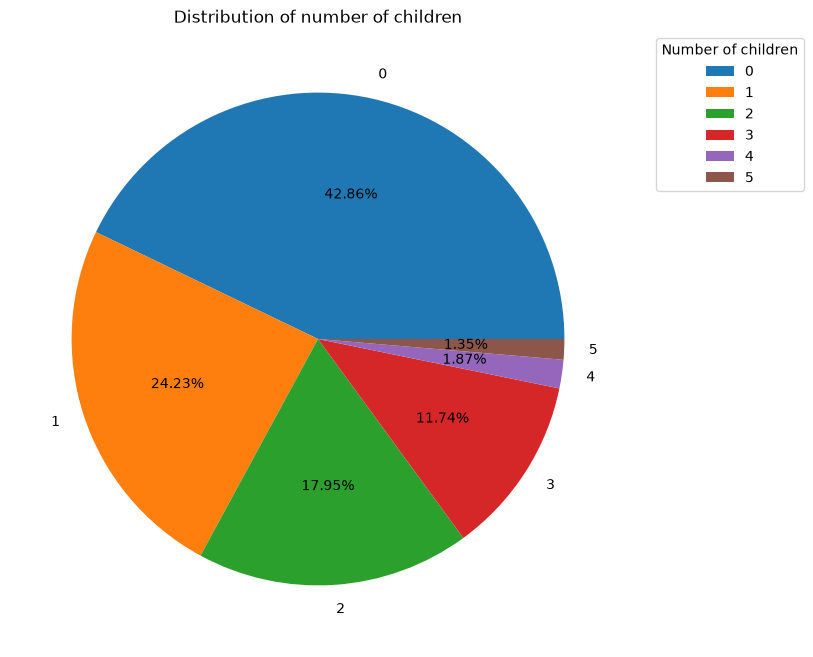

In [10]:
#no of children pie plot
import matplotlib.pyplot as plt
children_count =df['children'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(children_count.values, labels=children_count.index.values, autopct='%1.2f%%')
plt.title('Distribution of number of children')
plt.legend(title='Number of children', loc='upper right' , bbox_to_anchor=(1.3, 1))
plt.show()

In [11]:
df[['region','expenses']].groupby("region").sum()

,expenses
region,
northeast,4343668.64
northwest,4034072.37
southeast,5363689.80
southwest,4012754.82


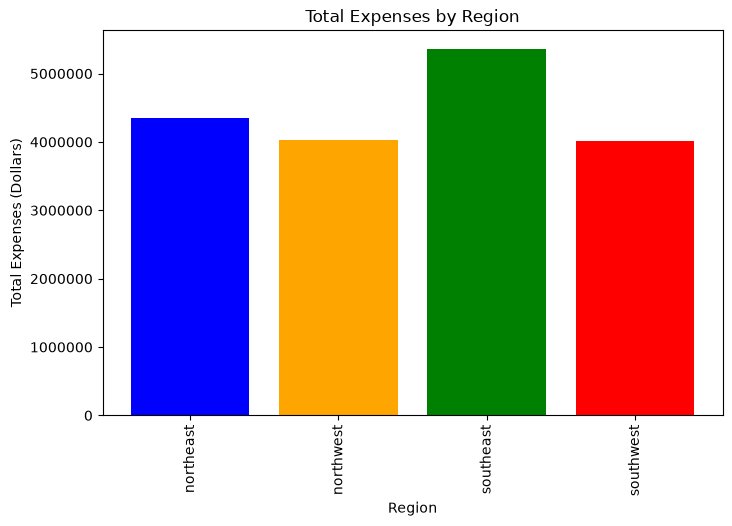

In [12]:
#region vs expenses barplot
import matplotlib.pyplot as plt

plt1 = df.groupby("region")["expenses"].sum()

plt.figure(figsize=(8,5))
plt.bar(plt1.index, plt1.values, color=['blue', 'orange', 'green', 'red'])

plt.xlabel("Region")
plt.ylabel("Total Expenses (Dollars)")

plt.title("Total Expenses by Region")
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=90)
plt.show()

In [13]:
df[['region','children']].groupby("region").mean()

,children
region,
northeast,1.046296
northwest,1.151235
southeast,1.049451
southwest,1.141538


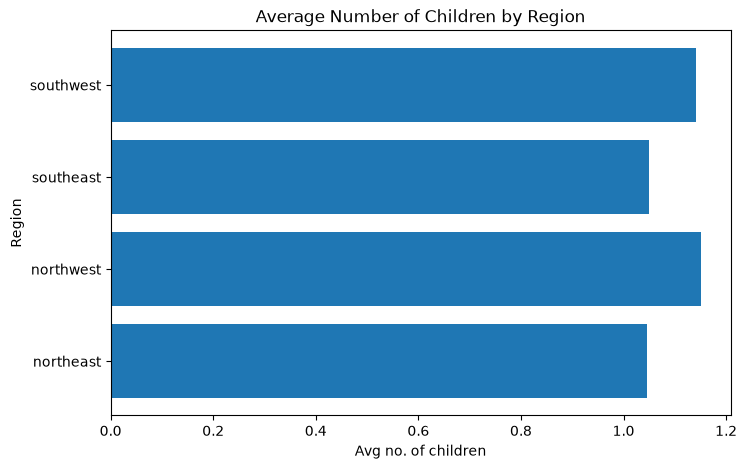

In [14]:
#region vs avg no of children
import matplotlib.pyplot as plt

plt1 = df[['region','children']].groupby("region").mean()
plt.figure(figsize=(8,5))

plt.barh(plt1.index, plt1['children'])

plt.xlabel("Avg no. of children")
plt.ylabel("Region")
plt.title("Average Number of Children by Region")
plt.show()

In [15]:
df[['children','expenses']].groupby("children").mean().reset_index()

,children,expenses
0,0,12384.695515
1,1,12731.171821
2,2,15073.564000
3,3,15355.318535
4,4,13850.656800
5,5,8786.035556


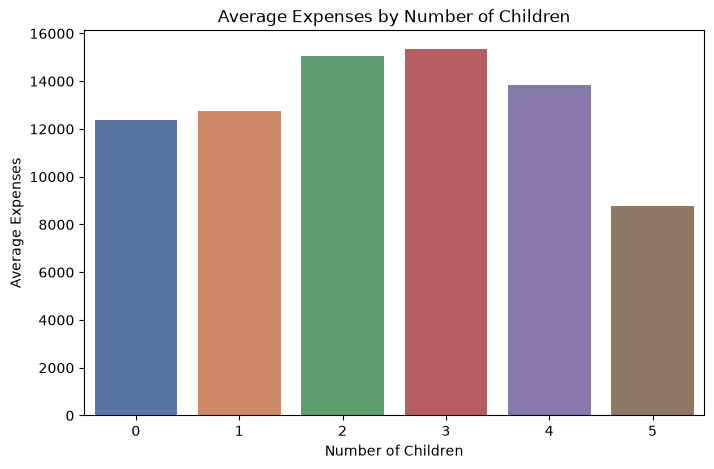

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt_df = df.groupby("children")["expenses"].mean().reset_index()

plt.figure(figsize=(8,5))
colors = sns.color_palette("deep", len(plt_df))

sns.barplot(
    data=plt_df,
    x='children',
    y='expenses',
    palette=colors,
    hue='children',
    legend=False
)

plt.title("Average Expenses by Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Average Expenses")

plt.show()

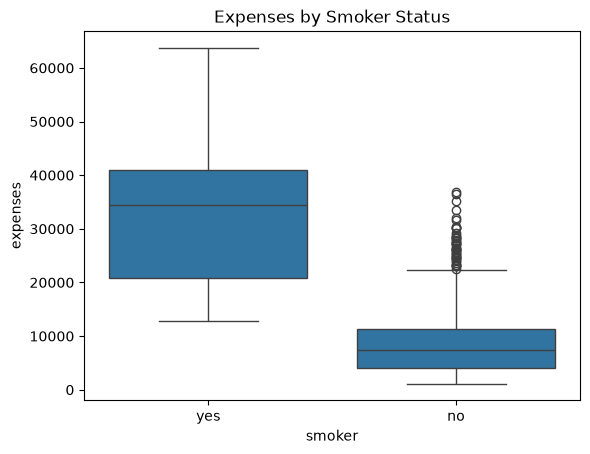

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x='smoker', y='expenses')
plt.title("Expenses by Smoker Status")
plt.show()

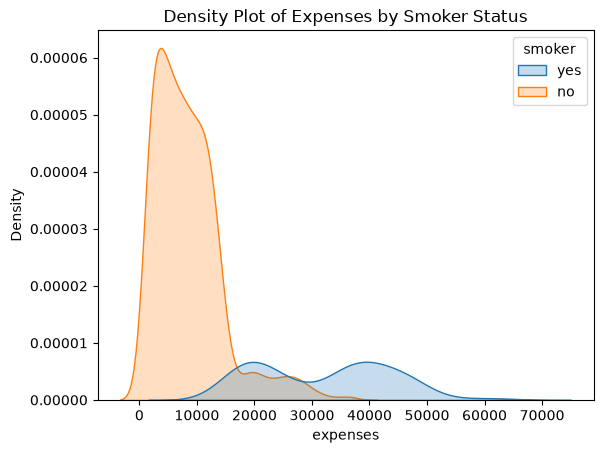

In [18]:
sns.kdeplot(data=df, x='expenses', hue='smoker', fill=True)
plt.title("Density Plot of Expenses by Smoker Status")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [19]:
df[['smoker','bmi']].groupby("smoker").mean()

,bmi
smoker,
no,30.653246
yes,30.713139


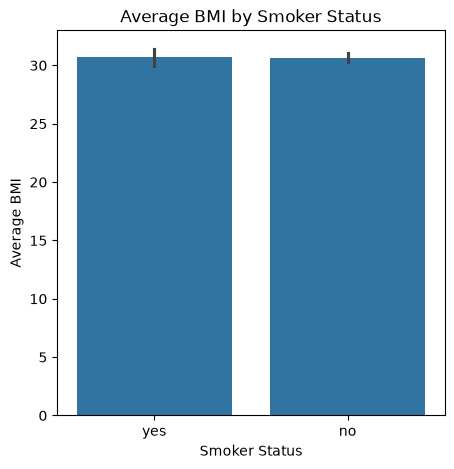

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,5))
sns.barplot(data=df, x='smoker', y='bmi')
plt.title("Average BMI by Smoker Status")
plt.xlabel("Smoker Status")
plt.ylabel("Average BMI")
plt.show()

In [21]:
selected_columns=df[['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses']]

In [22]:
selected_columns

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


<Figure size 1500x1500 with 0 Axes>

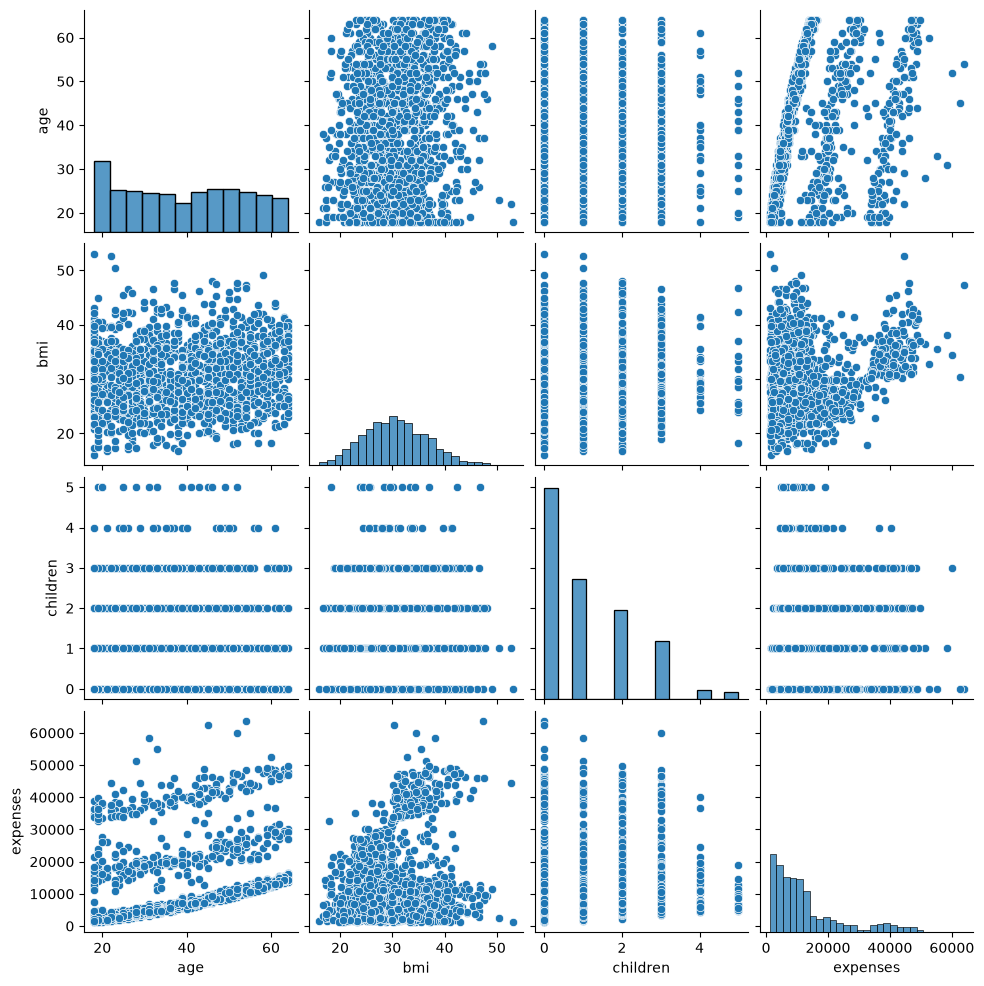

In [23]:
plt.figure(figsize=(15, 15))
sns.pairplot(selected_columns)
plt.show()

In [24]:
df

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


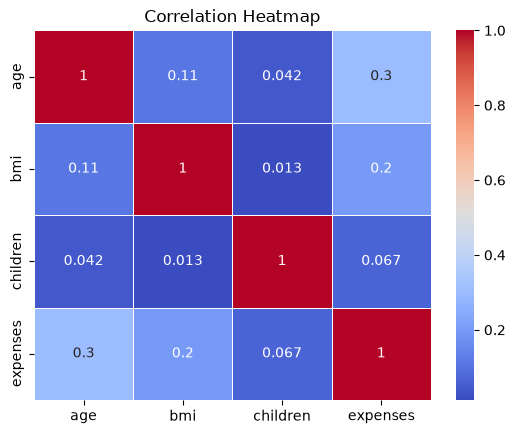

In [25]:
num_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Identifying and Removing Multicollinearity

In [26]:
corr_matrix = num_df.corr().abs()

columns_to_drop = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.8:
            columns_to_drop.append(corr_matrix.columns[i])

print(columns_to_drop)
            

[]


In [27]:
df = df.reset_index(drop=True)

## Splitting the data for training

In [28]:
df

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1332,50,male,31.0,3,no,northwest,10600.55
1333,18,female,31.9,0,no,northeast,2205.98
1334,18,female,36.9,0,no,southeast,1629.83
1335,21,female,25.8,0,no,southwest,2007.95


`random_state is a seed value that makes random operations produce the same result every time you run the code.`

In [29]:
from sklearn.model_selection import train_test_split
df_train, df_test = train_test_split(df, train_size = 0.7, test_size = 0.3, random_state = 1)

In [30]:
df_train.head()

,age,sex,bmi,children,smoker,region,expenses
520,50,female,27.4,0,no,northeast,25656.58
575,58,female,27.2,0,no,northwest,12222.90
769,61,male,36.1,3,no,southwest,27941.29
314,27,female,31.4,0,yes,southwest,34838.87
426,38,female,27.3,1,no,northeast,6555.07


In [31]:
df_test.head()

,age,sex,bmi,children,smoker,region,expenses
628,44,female,39.0,0,yes,northwest,42983.46
1086,57,male,31.5,0,no,northwest,11353.23
283,55,female,32.4,1,no,northeast,11879.10
789,39,female,41.8,0,no,southeast,5662.23
593,41,male,40.3,0,no,southeast,5709.16


In [32]:
print("the shape of the train data set is : ", df_train.shape)
print("the shape of the test data set is : ", df_test.shape)

the shape of the train data set is :  (935, 7)
the shape of the test data set is :  (402, 7)


In [33]:
df_train.head()

,age,sex,bmi,children,smoker,region,expenses
520,50,female,27.4,0,no,northeast,25656.58
575,58,female,27.2,0,no,northwest,12222.90
769,61,male,36.1,3,no,southwest,27941.29
314,27,female,31.4,0,yes,southwest,34838.87
426,38,female,27.3,1,no,northeast,6555.07


# Feature Encoding

In [34]:
# select the categorical columns
categorical_features =df_train.select_dtypes(include=['object']).columns.tolist()
categorical_features

/tmp/ipykernel_5461/1041514124.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features =df_train.select_dtypes(include=['object']).columns.tolist()


['sex', 'smoker', 'region']

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

train_transformed = ct.fit_transform(df_train.drop('expenses', axis=1))
test_transformed = ct.transform(df_test.drop('expenses', axis=1))

In [36]:
# Encoded column names
encoded_cols = ct.named_transformers_['ohe'].get_feature_names_out(categorical_features)
print(list(encoded_cols))

['sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


In [37]:
# Remaining columns (exclude the target 'expenses' so it isn't treated as a feature)
remaining_cols = [col for col in df.columns if col not in categorical_features and col != 'expenses']
print(list(remaining_cols))

['age', 'bmi', 'children']


In [38]:
# Combine names
all_cols = list(encoded_cols) + remaining_cols
all_cols

['sex_male',
 'smoker_yes',
 'region_northwest',
 'region_southeast',
 'region_southwest',
 'age',
 'bmi',
 'children']

In [39]:
# DataFrame of features only
df_train_encoded = pd.DataFrame(train_transformed, columns=all_cols)
df_test_encoded = pd.DataFrame(test_transformed, columns=all_cols)
# Re-attach the target column so the existing train_test_split + pop('expenses') flow keeps working
df_train_encoded['expenses'] = df_train['expenses'].values
df_test_encoded['expenses'] = df_test['expenses'].values

In [40]:
df_train_encoded.head()

,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,age,bmi,children,expenses
0,0.0,0.0,0.0,0.0,0.0,50.0,27.4,0.0,25656.58
1,0.0,0.0,1.0,0.0,0.0,58.0,27.2,0.0,12222.90
2,1.0,0.0,0.0,0.0,1.0,61.0,36.1,3.0,27941.29
3,0.0,1.0,0.0,0.0,1.0,27.0,31.4,0.0,34838.87
4,0.0,0.0,0.0,0.0,0.0,38.0,27.3,1.0,6555.07


In [41]:
df_test_encoded.head()

,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,age,bmi,children,expenses
0,0.0,1.0,1.0,0.0,0.0,44.0,39.0,0.0,42983.46
1,1.0,0.0,1.0,0.0,0.0,57.0,31.5,0.0,11353.23
2,0.0,0.0,0.0,0.0,0.0,55.0,32.4,1.0,11879.10
3,0.0,0.0,0.0,1.0,0.0,39.0,41.8,0.0,5662.23
4,1.0,0.0,0.0,1.0,0.0,41.0,40.3,0.0,5709.16


## Feature Scaling

In [42]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# Scale only features, NOT the target variable
df_train_encoded[['age', 'bmi', 'children']] = scaler.fit_transform(df_train_encoded[['age', 'bmi', 'children']])
df_test_encoded[['age', 'bmi', 'children']] = scaler.transform(df_test_encoded[['age', 'bmi', 'children']])

In [43]:
df_train_encoded.sample(2)

,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,age,bmi,children,expenses
193,1.0,0.0,0.0,0.0,1.0,0.021739,0.312668,0.0,1252.41
557,0.0,0.0,1.0,0.0,0.0,0.739130,0.579515,0.4,33471.97


In [44]:
df_test_encoded.sample(2)

,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,age,bmi,children,expenses
297,0.0,0.0,0.0,0.0,0.0,0.478261,0.256065,0.2,7077.19
109,1.0,0.0,0.0,1.0,0.0,0.000000,0.196765,0.2,1711.03


## Preparing the Input variable and Target Variable

In [45]:
y_train = df_train_encoded.pop('expenses')
X_train = df_train_encoded

In [46]:
y_test = df_test_encoded.pop('expenses')
X_test = df_test_encoded

In [47]:
y_train

0      25656.58
1      12222.90
2      27941.29
3      34838.87
4       6555.07
         ...   
930     9566.99
931     4846.92
932     1674.63
933    19444.27
934    48970.25
Name: expenses, Length: 935, dtype: float64

In [48]:
X_train

,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,age,bmi,children
0,0.0,0.0,0.0,0.0,0.0,0.695652,0.307278,0.0
1,0.0,0.0,1.0,0.0,0.0,0.869565,0.301887,0.0
2,1.0,0.0,0.0,0.0,1.0,0.934783,0.541779,0.6
3,0.0,1.0,0.0,0.0,1.0,0.195652,0.415094,0.0
4,0.0,0.0,0.0,0.0,0.0,0.434783,0.304582,0.2
...,...,...,...,...,...,...,...,...
930,0.0,0.0,1.0,0.0,0.0,0.673913,0.177898,0.2
931,1.0,0.0,0.0,0.0,0.0,0.195652,0.447439,0.6
932,1.0,0.0,0.0,1.0,0.0,0.086957,0.479784,0.0
933,0.0,1.0,0.0,1.0,0.0,0.478261,0.167116,0.4


In [49]:
# Importing RFE and LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Select top 5 features
rfe = RFE(estimator=model, n_features_to_select=6)

# Fit RFE
X_rfe = rfe.fit_transform(X_train, y_train)

# Selected feature names
selected_features = X_train.columns[rfe.support_]

print("Selected Features:")
print(list(selected_features))



Selected Features:
['smoker_yes', 'region_southeast', 'region_southwest', 'age', 'bmi', 'children']


In [50]:
feature_ranking = pd.DataFrame({
    'Feature': X_train.columns,
    'Selected': rfe.support_,
    'Rank': rfe.ranking_
})

feature_ranking.sort_values('Rank').reset_index(drop=True)

,Feature,Selected,Rank
0,smoker_yes,True,1
1,region_southeast,True,1
2,age,True,1
3,region_southwest,True,1
4,bmi,True,1
5,children,True,1
6,sex_male,False,2
7,region_northwest,False,3


In [51]:
X_train_final = X_train[selected_features]

lr = LinearRegression()
lr.fit(X_train_final, y_train)
y_pred = lr.predict(X_test[selected_features])

In [52]:
for i, (feature, coef) in enumerate(zip(selected_features, lr.coef_), start=1):
    print(f"{feature} (m{i}) : {coef}")

print(f"Bias (b) : {lr.intercept_}")

smoker_yes (m1) : 23388.08218373817
region_southeast (m2) : -1048.5132457660175
region_southwest (m3) : -722.9795813923689
age (m4) : 11819.976773429176
bmi (m5) : 14612.239483412033
children (m6) : 2791.4345009216486
Bias (b) : -2865.893658789868


In [53]:
for i in zip(y_test[10:20], y_pred[10:20]):
    print(f"Actual: {i[0]}, Predicted: {i[1]}")

Actual: 12629.9, Predicted: 10225.56347302026
Actual: 6652.53, Predicted: 4908.2647351116675
Actual: 9869.81, Predicted: 11208.372572169048
Actual: 9095.07, Predicted: 8812.012898712263
Actual: 1137.47, Predicted: 3332.6337017724527
Actual: 13352.1, Predicted: 13954.223716261775
Actual: 21984.47, Predicted: 3627.314640284856
Actual: 38746.36, Predicted: 32784.51805040744
Actual: 12646.21, Predicted: 16213.925071312431
Actual: 15161.53, Predicted: 16294.812527178448


In [54]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.7354756115575587
MAE: 4190.694589247979
RMSE: 6019.405953912504


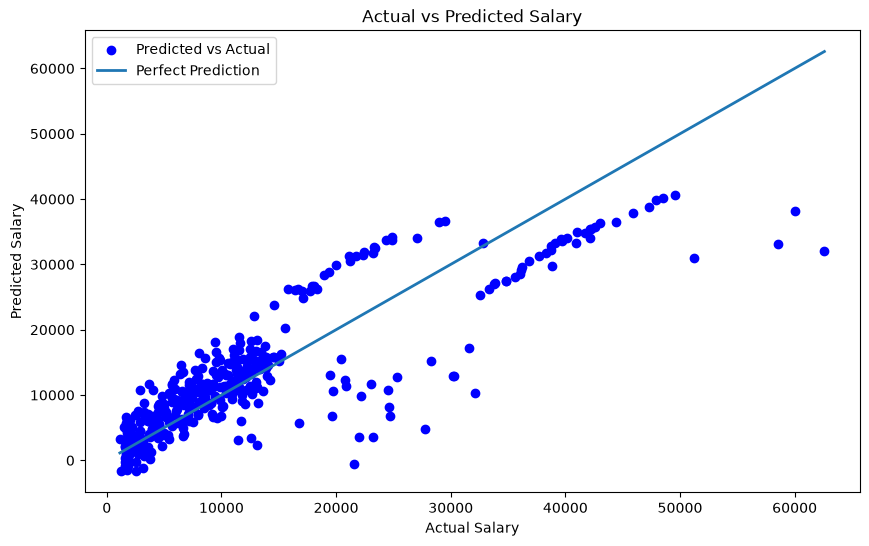

In [55]:
# line draw
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], lw=2, label='Perfect Prediction')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary')
plt.legend()
plt.show()

## Inference on the trained Model

In [1]:
import gradio as gr
def predict_expenses(age, sex, bmi, children, smoker, region):
    input_df=pd.DataFrame({
        'age': [age],
        'sex': [sex],
        'bmi': [bmi],
        'children': [children],
        'smoker': [smoker],
        'region': [region]
    })
    
    # doing the transformation (encoding and scaling) on the input data
    # feature encoding
    input_transformed = ct.transform(input_df)
    all_cols = list(ct.named_transformers_['ohe'].get_feature_names_out(categorical_features)) + ['age', 'bmi', 'children']
    input_transformed_df = pd.DataFrame(input_transformed, columns=all_cols)
    # feature scaling
    input_transformed_df[['age', 'bmi', 'children']] = scaler.transform(input_transformed_df[['age', 'bmi', 'children']])
    # selecting the features which were selected by RFE
    input_final = input_transformed_df[selected_features]
    # making the prediction
    prediction = lr.predict(input_final)
    return f"Estimated Insurance Expense: ${prediction[0]:,.2f}"

gr.Interface(
    fn=predict_expenses,
    inputs=[
        gr.Number(label="Age"),
        gr.Dropdown(label="Sex", choices=["male", "female"]),
        gr.Number(label="BMI"),
        gr.Number(label="Number of Children"),
        gr.Dropdown(label="Smoker", choices=["yes", "no"]),
        gr.Dropdown(label="Region", choices=["northeast", "northwest", "southeast", "southwest"])
    ],
    outputs="text",
    flagging_mode="never"
).launch()

/home/chris/Documents/Broadway Python/Lesson 1/venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "/home/chris/Documents/Broadway Python/Lesson 1/venv/lib64/python3.14/site-packages/gradio/queueing.py", line 867, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
    )
    ^
  File "/home/chris/Documents/Broadway Python/Lesson 1/venv/lib64/python3.14/site-packages/gradio/route_utils.py", line 393, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<11 lines>...
    )
    ^
  File "/home/chris/Documents/Broadway Python/Lesson 1/venv/lib64/python3.14/site-packages/gradio/blocks.py", line 2280, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<8 lines>...
    )
    ^
  File "/home/chris/Documents/Broadway Python/Lesson 1/venv/lib64/python3.14/site-packages/gradio/blocks.py", line 1657, in call_function
    prediction = await anyio.to

In [58]:
df

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1332,50,male,31.0,3,no,northwest,10600.55
1333,18,female,31.9,0,no,northeast,2205.98
1334,18,female,36.9,0,no,southeast,1629.83
1335,21,female,25.8,0,no,southwest,2007.95


In [59]:
df.iloc[[1078]]

,age,sex,bmi,children,smoker,region,expenses
1078,63,male,33.7,3,no,southeast,15161.53


In [60]:
import pandas as pd

def predict_expenses(age, sex, bmi, children, smoker, region):
    input_df = pd.DataFrame({
        'age': [age],
        'sex': [sex],
        'bmi': [bmi],
        'children': [children],
        'smoker': [smoker],
        'region': [region]
    })

    # Feature encoding
    input_transformed = ct.transform(input_df)

    all_cols = (
        list(ct.named_transformers_['ohe'].get_feature_names_out(categorical_features))
        + ['age', 'bmi', 'children']
    )

    input_transformed_df = pd.DataFrame(
        input_transformed,
        columns=all_cols
    )

    # Feature scaling
    input_transformed_df[['age', 'bmi', 'children']] = scaler.transform(
        input_transformed_df[['age', 'bmi', 'children']]
    )

    # Select RFE features
    input_final = input_transformed_df[selected_features]

    # Prediction
    prediction = lr.predict(input_final)[0]

    return prediction


# Example prediction
expense = predict_expenses(
    age=63,
    sex='male',
    bmi=33.7,
    children=3,
    smoker='no',
    region='southeast'
)

print(f"Estimated Insurance Expense: ${expense:,.2f}")

Estimated Insurance Expense: $16,294.81
